In [2]:
import torch
print("Torch version:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Torch version: 2.11.0+cu128
CUDA build: 12.8
CUDA available: True
Device count: 1
GPU name: NVIDIA GeForce RTX 4050 Laptop GPU


Cell 1 — Imports

In [3]:
import os
import gc
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from datasets import load_from_disk

Cell 2 — Seed and device

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


Cell 3 — Paths

In [5]:
DATASET_PATH = "D:/plant_disease_data/bd_crop_dataset"
MODEL_SAVE_DIR = "E:/Research/Multi-crop-plant-disease-detection/models"
OUTPUT_DIR = "E:/Research/Multi-crop-plant-disease-detection/outputs"

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "tables"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "figures"), exist_ok=True)

Cell 4 — Load local dataset

In [6]:
ds = load_from_disk(DATASET_PATH)
print(ds)

Loading dataset from disk:   0%|          | 0/32 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'label_name'],
        num_rows: 86467
    })
    valid: Dataset({
        features: ['image', 'label', 'label_name'],
        num_rows: 24698
    })
    test: Dataset({
        features: ['image', 'label', 'label_name'],
        num_rows: 12423
    })
})


Cell 5 — Class names

In [7]:
train_labels = ds["train"]["label_name"]
class_names = sorted(list(set(train_labels)))
num_classes = len(class_names)

label2id = {name: i for i, name in enumerate(class_names)}
id2label = {i: name for name, i in label2id.items()}

print("Number of classes:", num_classes)
print("First 10 classes:", class_names[:10])

Number of classes: 94
First 10 classes: ['Banana_Black_Pitting_or_Banana_Rust', 'Banana_Crown_Rot', 'Banana_Healthy', 'Banana_fungal_disease', 'Banana_leaf_Banana_Scab_Moth', 'Banana_leaf_Black_Sigatoka', 'Banana_leaf_Healthy', 'Banana_leaf__Black_Leaf_Streak', 'Banana_leaf__Panama_Disease.', 'Cauliflower_Bacterial_spot_rot']


Cell 6 — Transforms

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

Cell 7 — Dataset wrapper

In [9]:
class HFDatasetWrapper(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        image = item["image"].convert("RGB")
        label_name = item["label_name"]
        label = label2id[label_name]

        if self.transform:
            image = self.transform(image)

        return image, label

Cell 8 — DataLoaders

In [27]:
train_dataset = HFDatasetWrapper(ds["train"], transform=train_transform)
val_dataset   = HFDatasetWrapper(ds["valid"], transform=val_test_transform)
test_dataset  = HFDatasetWrapper(ds["test"], transform=val_test_transform)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("Train batches:", len(train_loader))
print("Valid batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 2703
Valid batches: 772
Test batches: 389


Cell 9 — Model builders

In [21]:
def build_mobilenetv2(num_classes):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

def build_resnet50(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

def build_efficientnetv2s(num_classes):
    model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

Cell 10 — Train/validate helpers

In [22]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )

    return epoch_loss, acc, precision, recall, f1


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )

    return epoch_loss, acc, precision, recall, f1

Cell 11 — Test evaluation helper

In [23]:
def evaluate_model(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Testing", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )

    return acc, precision, recall, f1

Cell 12 — Training loop for one model

In [24]:
def train_model(model_name, model, train_loader, val_loader, test_loader, device, epochs=5, lr=1e-4):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=2, factor=0.5
    )

    best_val_f1 = 0.0
    best_model_path = os.path.join(MODEL_SAVE_DIR, f"{model_name.lower()}_best.pth")
    history = []

    for epoch in range(epochs):
        print(f"\n{model_name} | Epoch [{epoch+1}/{epochs}]")

        train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc, val_prec, val_rec, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        scheduler.step(val_f1)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_f1": train_f1,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1
        })

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), best_model_path)
            print("Best model saved.")

    best_model = type(model)(*[]) if False else None
    history_df = pd.DataFrame(history)

    return best_model_path, best_val_f1, history_df

Cell 13 — Model dictionary

In [29]:
model_builders = {
    "MobileNetV2": lambda: build_mobilenetv2(num_classes),
    "ResNet50": lambda: build_resnet50(num_classes),
    "EfficientNetV2S": lambda: build_efficientnetv2s(num_classes),
}

Cell 14 — Run comparison

In [30]:
EPOCHS = 5
LR = 1e-4

results = {}
histories = {}

for model_name, builder in model_builders.items():
    print(f"\n========== Training {model_name} ==========")

    model = builder()

    best_model_path, best_val_f1, history_df = train_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device,
        epochs=EPOCHS,
        lr=LR
    )

    histories[model_name] = history_df

    best_model = builder()
    best_model.load_state_dict(torch.load(best_model_path, map_location=device))
    best_model = best_model.to(device)

    test_acc, test_precision, test_recall, test_f1 = evaluate_model(
        best_model, test_loader, device
    )

    results[model_name] = {
        "Model": model_name,
        "Val Best F1": best_val_f1,
        "Test Accuracy": test_acc,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1-Score": test_f1
    }


========== Training MobileNetV2 ==========

MobileNetV2 | Epoch [1/5]


Train Loss: 0.7690 | Train Acc: 0.7782 | Train F1: 0.7703
Val   Loss: 0.2947 | Val   Acc: 0.8912 | Val   F1: 0.8821
Best model saved.

MobileNetV2 | Epoch [2/5]


Train Loss: 0.2834 | Train Acc: 0.8964 | Train F1: 0.8947
Val   Loss: 0.2157 | Val   Acc: 0.9188 | Val   F1: 0.9161
Best model saved.

MobileNetV2 | Epoch [3/5]


Train Loss: 0.2062 | Train Acc: 0.9216 | Train F1: 0.9209
Val   Loss: 0.1624 | Val   Acc: 0.9333 | Val   F1: 0.9298
Best model saved.

MobileNetV2 | Epoch [4/5]


Train Loss: 0.1633 | Train Acc: 0.9358 | Train F1: 0.9354
Val   Loss: 0.1540 | Val   Acc: 0.9381 | Val   F1: 0.9342
Best model saved.

MobileNetV2 | Epoch [5/5]


...

Train Loss: 0.5400 | Train Acc: 0.8381 | Train F1: 0.8348
Val   Loss: 0.2235 | Val   Acc: 0.9159 | Val   F1: 0.9133
Best model saved.

EfficientNetV2S | Epoch [2/5]


Train Loss: 0.1979 | Train Acc: 0.9245 | Train F1: 0.9240
Val   Loss: 0.1560 | Val   Acc: 0.9399 | Val   F1: 0.9389
Best model saved.

EfficientNetV2S | Epoch [3/5]


Train Loss: 0.1418 | Train Acc: 0.9443 | Train F1: 0.9441
Val   Loss: 0.1277 | Val   Acc: 0.9491 | Val   F1: 0.9481
Best model saved.

EfficientNetV2S | Epoch [4/5]


Train Loss: 0.1168 | Train Acc: 0.9531 | Train F1: 0.9531
Val   Loss: 0.1158 | Val   Acc: 0.9554 | Val   F1: 0.9548
Best model saved.

EfficientNetV2S | Epoch [5/5]


Train Loss: 0.1014 | Train Acc: 0.9588 | Train F1: 0.9588
Val   Loss: 0.0999 | Val   Acc: 0.9583 | Val   F1: 0.9581
Best model saved.


Cell 15 — Comparison table

In [31]:
results_df = pd.DataFrame(results.values()).sort_values(
    by="Test F1-Score", ascending=False
).reset_index(drop=True)

results_df

,Model,Val Best F1,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,EfficientNetV2S,0.958126,0.957498,0.960570,0.957498,0.957101
1,ResNet50,0.956477,0.955486,0.956240,0.955486,0.954990
2,MobileNetV2,0.946513,0.945343,0.946637,0.945343,0.944431


Cell 16 — Save comparison table

In [32]:
results_path = os.path.join(OUTPUT_DIR, "tables", "model_comparison_results.csv")
results_df.to_csv(results_path, index=False)

print("Saved to:", results_path)

Saved to: E:/Research/Multi-crop-plant-disease-detection/outputs\tables\model_comparison_results.csv


Cell 17 — Plot final comparison

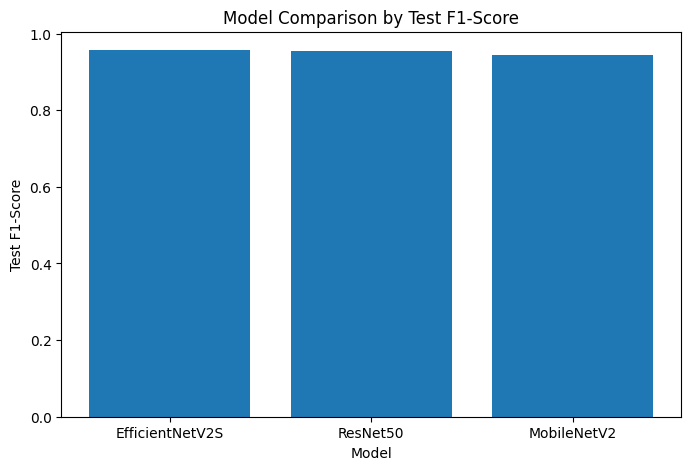

In [33]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Test F1-Score"])
plt.xlabel("Model")
plt.ylabel("Test F1-Score")
plt.title("Model Comparison by Test F1-Score")
plt.show()

Cell 18 — Plot validation F1 histories

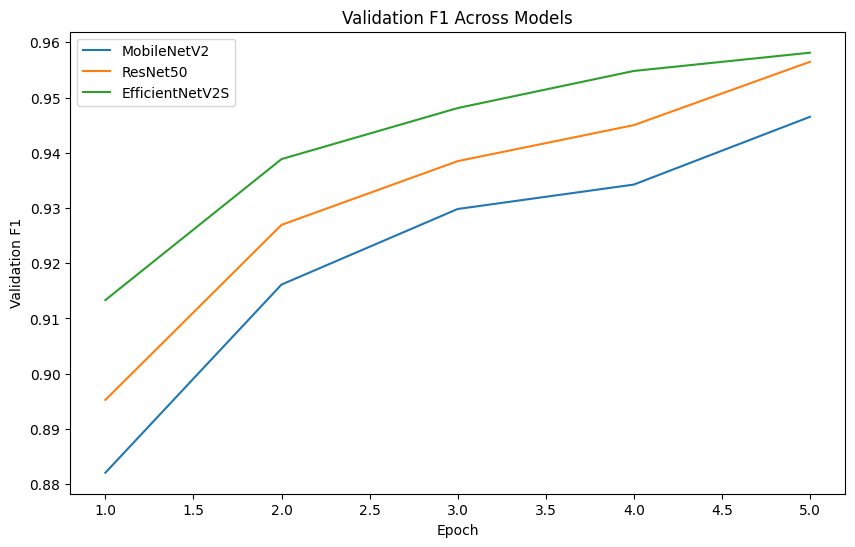

In [34]:
plt.figure(figsize=(10, 6))

for model_name, history_df in histories.items():
    plt.plot(history_df["epoch"], history_df["val_f1"], label=model_name)

plt.xlabel("Epoch")
plt.ylabel("Validation F1")
plt.title("Validation F1 Across Models")
plt.legend()
plt.show()

In [35]:
results_df

,Model,Val Best F1,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,EfficientNetV2S,0.958126,0.957498,0.960570,0.957498,0.957101
1,ResNet50,0.956477,0.955486,0.956240,0.955486,0.954990
2,MobileNetV2,0.946513,0.945343,0.946637,0.945343,0.944431


In [36]:
results_path = os.path.join(OUTPUT_DIR, "tables", "model_comparison_results.csv")
results_df.to_csv(results_path, index=False)

print("Saved to:", results_path)

Saved to: E:/Research/Multi-crop-plant-disease-detection/outputs\tables\model_comparison_results.csv


Cell 19 — Imports for analysis

In [37]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Cell 20 — Load best EfficientNetV2S model

In [38]:
best_model_name = "EfficientNetV2S"
best_model_path = os.path.join(MODEL_SAVE_DIR, "efficientnetv2s_best.pth")

best_model = build_efficientnetv2s(num_classes)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_model = best_model.to(device)
best_model.eval()

print("Loaded best model from:", best_model_path)

Loaded best model from: E:/Research/Multi-crop-plant-disease-detection/models\efficientnetv2s_best.pth


Cell 21 — Get predictions on test set

In [39]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing best model"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

print("Total test samples:", len(all_labels))

Testing best model: 100%|██████████| 389/389 [05:50<00:00,  1.11it/s]

Total test samples: 12423


Cell 22 — Classification report

In [40]:
report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_df.head()

,precision,recall,f1-score,support
Banana_Black_Pitting_or_Banana_Rust,0.790262,0.531486,0.635542,397.0
Banana_Crown_Rot,0.647059,0.379310,0.478261,29.0
Banana_Healthy,0.684211,0.722222,0.702703,18.0
Banana_fungal_disease,0.574822,0.855124,0.687500,283.0
Banana_leaf_Banana_Scab_Moth,0.909091,1.000000,0.952381,10.0


Cell 23 — Save classification report CSV

In [41]:
report_path = os.path.join(OUTPUT_DIR, "tables", "efficientnetv2s_classification_report.csv")
report_df.to_csv(report_path)

print("Saved classification report to:", report_path)

Saved classification report to: E:/Research/Multi-crop-plant-disease-detection/outputs\tables\efficientnetv2s_classification_report.csv


Cell 24 — Overall summary metrics only

In [42]:
summary_df = report_df.loc[["accuracy", "macro avg", "weighted avg"]]
summary_df

,precision,recall,f1-score,support
accuracy,0.957498,0.957498,0.957498,0.957498
macro avg,0.933704,0.926584,0.925152,12423.000000
weighted avg,0.960570,0.957498,0.957101,12423.000000


In [50]:
summary_path = os.path.join(OUTPUT_DIR, "tables", "efficientnetv2s_summary_metrics.csv")
summary_df.to_csv(summary_path)
print("Saved to:", summary_path)

Saved to: E:/Research/Multi-crop-plant-disease-detection/outputs\tables\efficientnetv2s_summary_metrics.csv


Cell 25 — Confusion matrix

In [43]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix shape:", cm.shape)

Confusion matrix shape: (94, 94)


Cell 26 — Plot confusion matrix

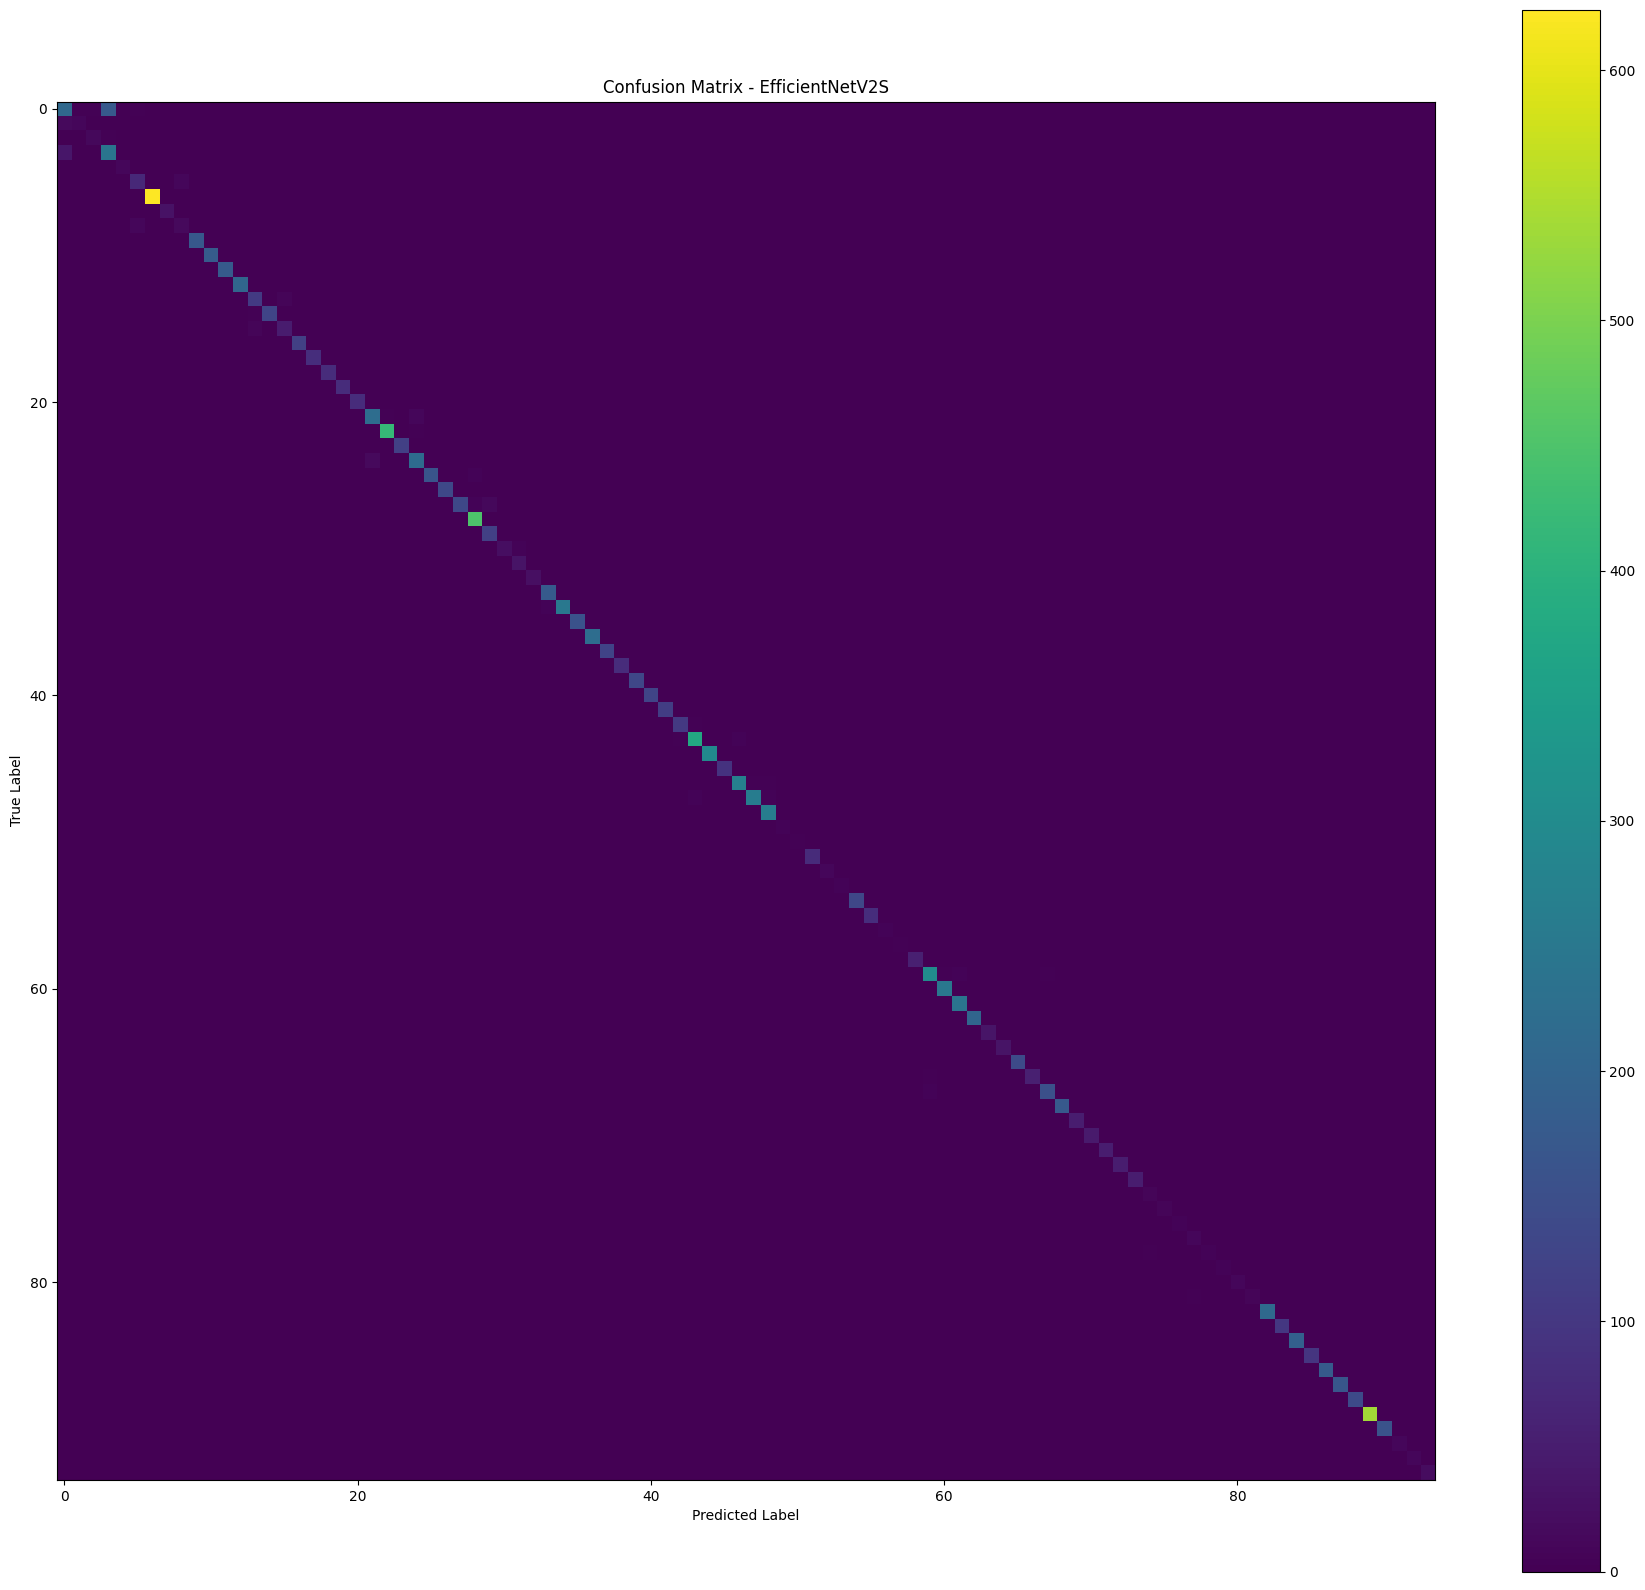

In [44]:
plt.figure(figsize=(18, 16))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - EfficientNetV2S")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

Cell 27 — Save confusion matrix image

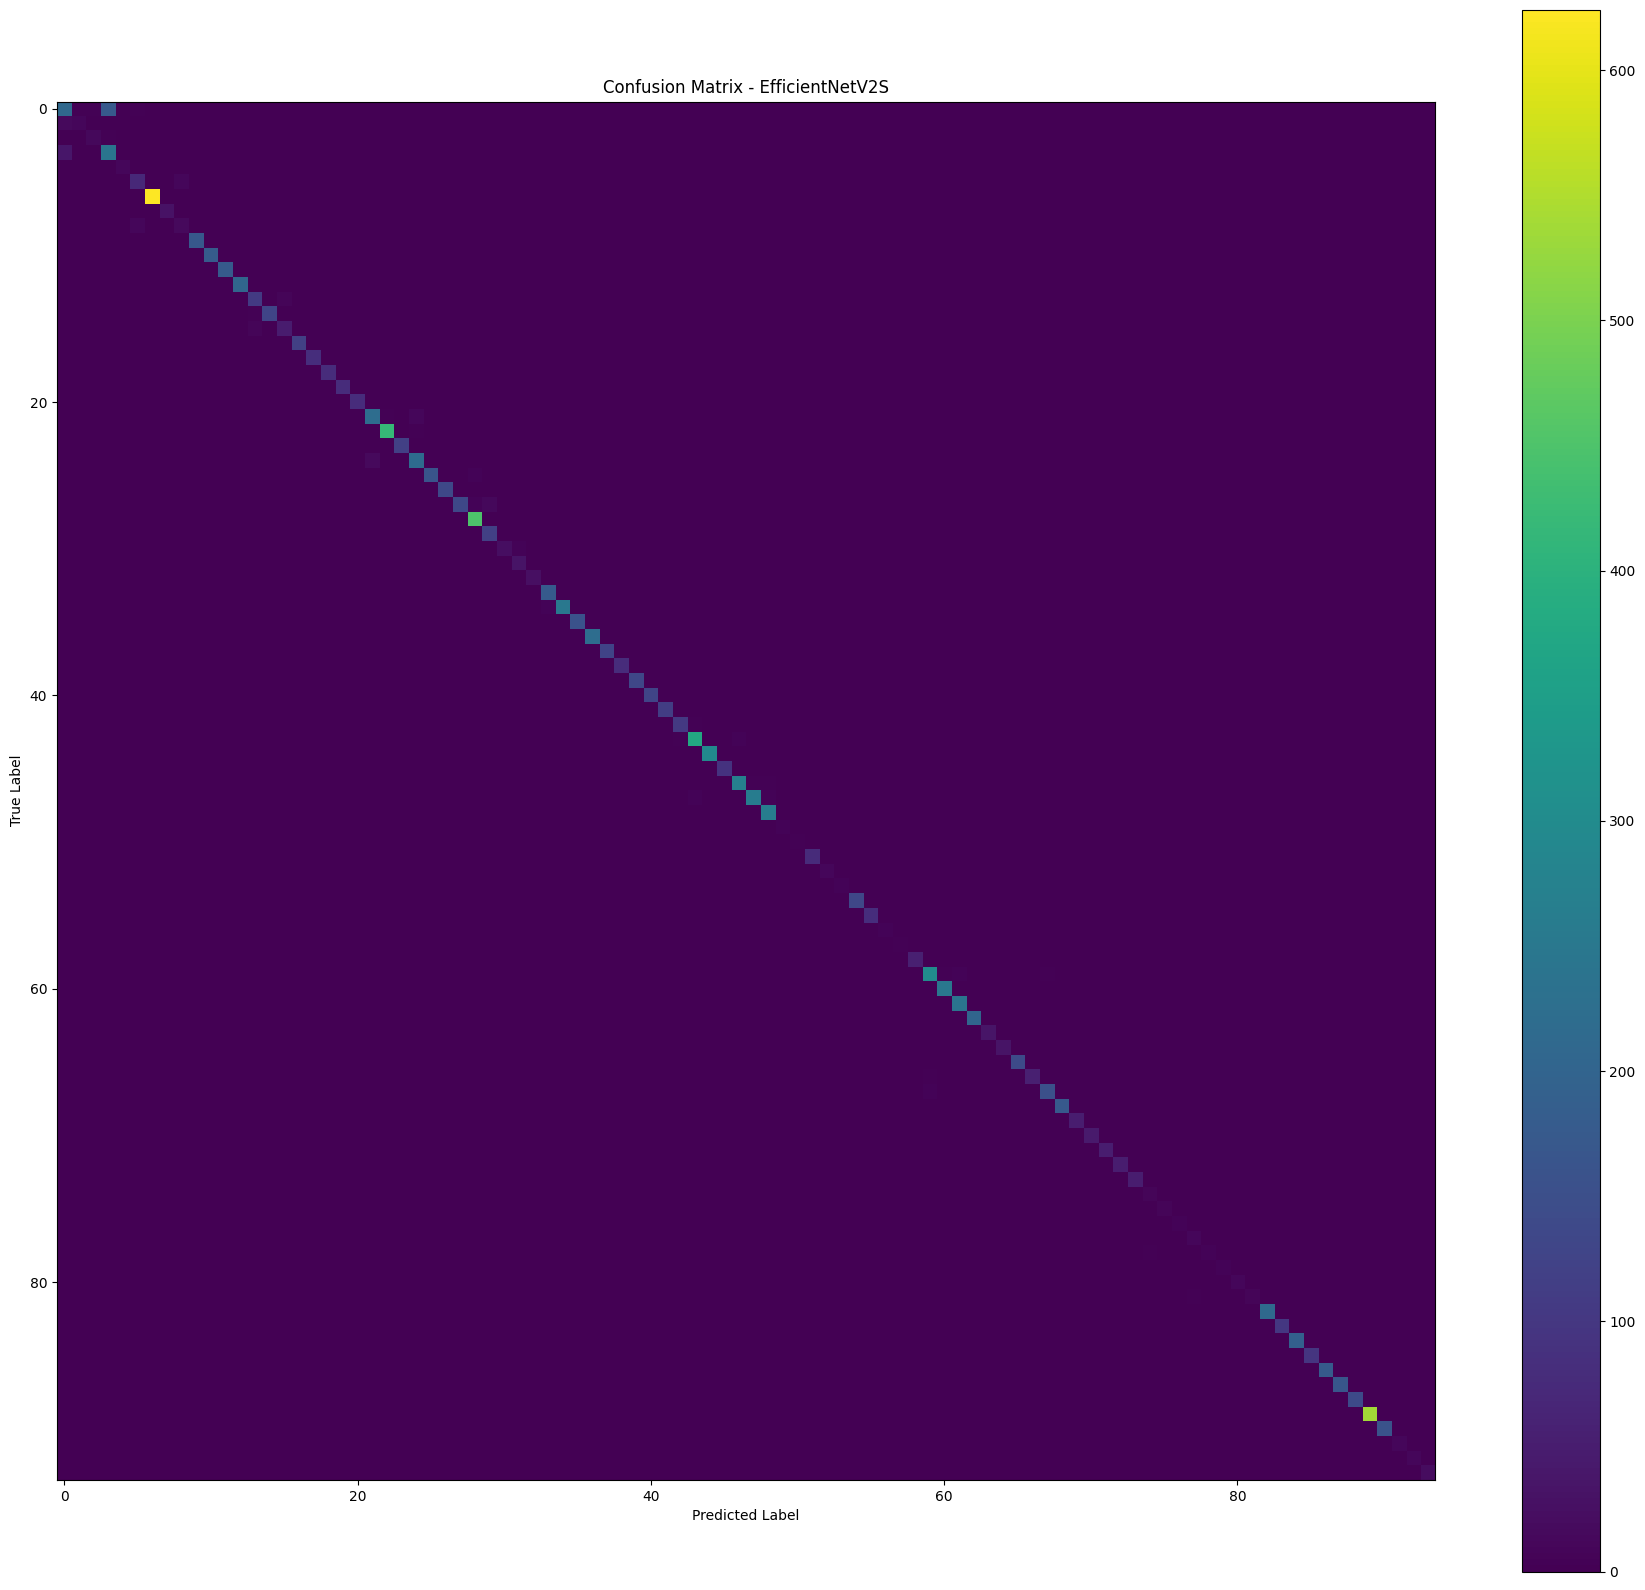

Saved confusion matrix figure to: E:/Research/Multi-crop-plant-disease-detection/outputs\figures\efficientnetv2s_confusion_matrix.png


In [45]:
cm_fig_path = os.path.join(OUTPUT_DIR, "figures", "efficientnetv2s_confusion_matrix.png")

plt.figure(figsize=(18, 16))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - EfficientNetV2S")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(cm_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix figure to:", cm_fig_path)

Cell 28 — Top classes by F1-score

In [46]:
per_class_df = report_df.iloc[:-3].copy()  # remove accuracy/macro avg/weighted avg rows
top_f1_df = per_class_df.sort_values(by="f1-score", ascending=False).head(10)
top_f1_df[["precision", "recall", "f1-score", "support"]]

,precision,recall,f1-score,support
Cauliflower_Healthy,1.0,1.0,1.0,206.0
Cauliflower_Bacterial_spot_rot,1.0,1.0,1.0,173.0
Cauliflower_Black_Rot,1.0,1.0,1.0,180.0
Cauliflower_Downy_Mildew,1.0,1.0,1.0,177.0
Corn_Healthy,1.0,1.0,1.0,117.0
Tomato_healthy,1.0,1.0,1.0,160.0
Tomato_Septoria_Leaf_Spot,1.0,1.0,1.0,178.0
Potato_Blackspot_Bruising,1.0,1.0,1.0,77.0
Potato_Soft_Rot,1.0,1.0,1.0,56.0
Potato_Healthy_Potatoes,1.0,1.0,1.0,82.0


Cell 29 — Lowest-performing classes

In [47]:
low_f1_df = per_class_df.sort_values(by="f1-score", ascending=True).head(10)
low_f1_df[["precision", "recall", "f1-score", "support"]]

,precision,recall,f1-score,support
Banana_Crown_Rot,0.647059,0.379310,0.478261,29.0
Potato_Blackleg,0.400000,0.666667,0.500000,6.0
Banana_leaf__Panama_Disease.,0.586207,0.607143,0.596491,28.0
Potato_Pink_Rot,1.000000,0.428571,0.600000,7.0
Potato_Miscellaneous,0.714286,0.555556,0.625000,9.0
Banana_Black_Pitting_or_Banana_Rust,0.790262,0.531486,0.635542,397.0
Banana_fungal_disease,0.574822,0.855124,0.687500,283.0
Banana_Healthy,0.684211,0.722222,0.702703,18.0
Potato_Common_Scab,0.625000,0.833333,0.714286,6.0
Tea_Anthracnose,0.571429,1.000000,0.727273,8.0


Cell 30 — Plot lowest-performing class F1-scores

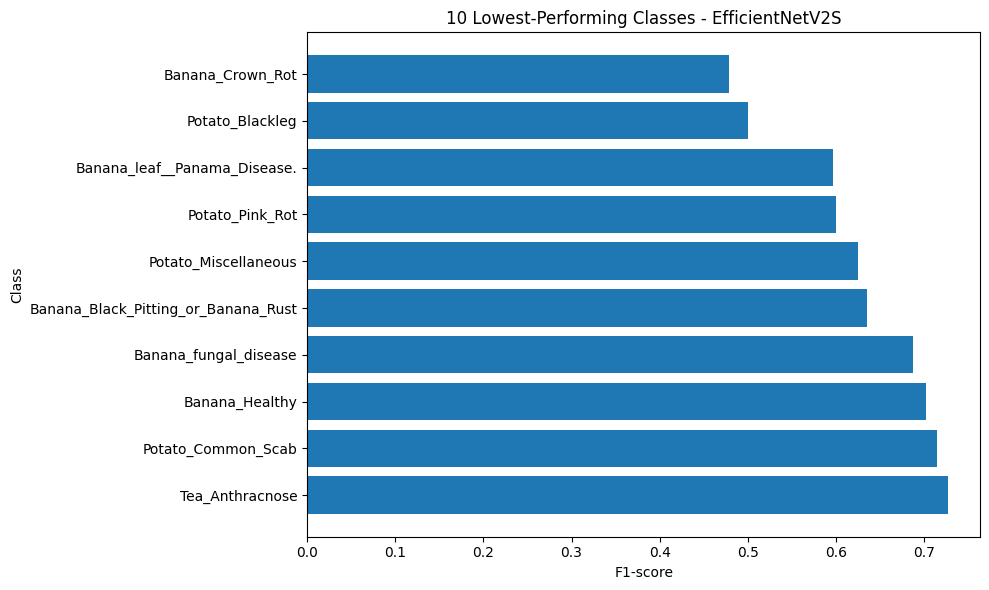

In [48]:
low_plot_df = low_f1_df.reset_index().rename(columns={"index": "class_name"})

plt.figure(figsize=(10, 6))
plt.barh(low_plot_df["class_name"], low_plot_df["f1-score"])
plt.xlabel("F1-score")
plt.ylabel("Class")
plt.title("10 Lowest-Performing Classes - EfficientNetV2S")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Cell 31 — Save low-performing class table

In [49]:
low_f1_path = os.path.join(OUTPUT_DIR, "tables", "efficientnetv2s_low_f1_classes.csv")
low_f1_df.to_csv(low_f1_path)

print("Saved low-F1 class table to:", low_f1_path)

Saved low-F1 class table to: E:/Research/Multi-crop-plant-disease-detection/outputs\tables\efficientnetv2s_low_f1_classes.csv
